<a href="https://colab.research.google.com/github/choudhary168/choudhary168/blob/main/Stock_Prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from io import IncrementalNewlineDecoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib Inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense
from sklearn.preprocessing import minmax_scale

In [2]:
df=pd.read_csv("/content/stock_data.csv")
df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB


In [4]:
df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [5]:
df.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
Date,,,,,
2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [6]:
df.isnull().sum()

,0
Stock_1,0
Stock_2,0
Stock_3,0
Stock_4,0
Stock_5,0


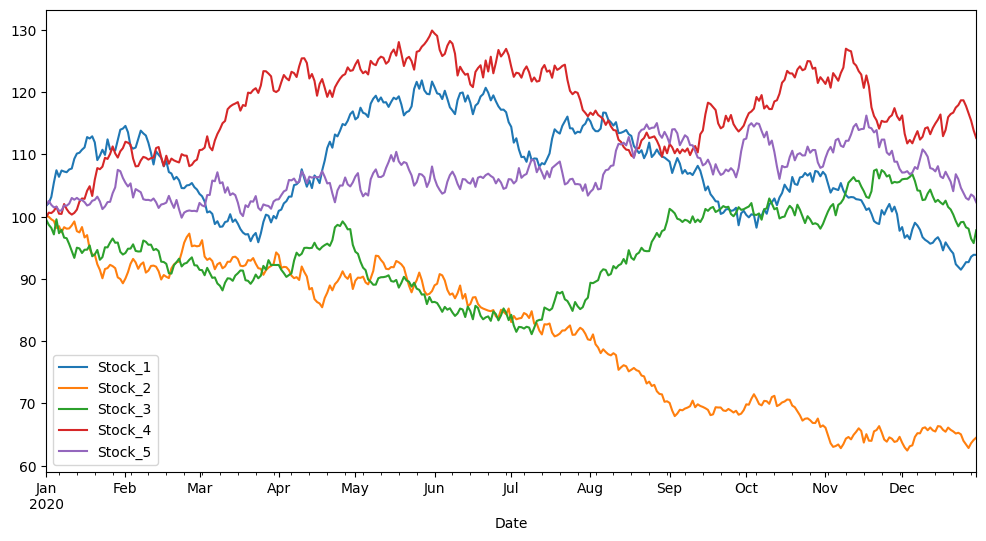

In [7]:
df.plot(figsize=(12,6))
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.iloc[:, :5])

In [9]:
stock = scaled_data[:, 0]

In [10]:

X = []
y = []

for i in range(60, len(stock)):
    X.append(stock[i-60:i])
    y.append(stock[i])

X = np.array(X)
y = np.array(y)

In [11]:
print(X.shape)
print(y.shape)

(305, 60)
(305,)


In [12]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(305, 60, 1)


In [13]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(244, 60, 1)
(61, 60, 1)


In [14]:
print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)

(305, 60, 1)
(305,)
(244, 60, 1)
(61, 60, 1)


In [15]:

model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(60, 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(25))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.1530 - val_loss: 0.0859
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0346 - val_loss: 0.0091
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0268 - val_loss: 0.0236
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0180 - val_loss: 0.0270
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0179 - val_loss: 0.0135
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0173 - val_loss: 0.0218
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0136 - val_loss: 0.0131
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0148 - val_loss: 0.0127
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0131 - val_loss: 0.0123
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0096 - val_loss: 0.0089
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0094 - val_loss: 0.0082
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0116 - val_loss: 0.0080


In [17]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step


In [18]:
print(predictions.shape)

(61, 1)


In [19]:
dummy = np.zeros((len(predictions), 5))

dummy[:, 0] = predictions.flatten()

predicted_prices = scaler.inverse_transform(dummy)[:, 0]

In [20]:
dummy_actual = np.zeros((len(y_test), 5))

dummy_actual[:, 0] = y_test

actual_prices = scaler.inverse_transform(dummy_actual)[:, 0]

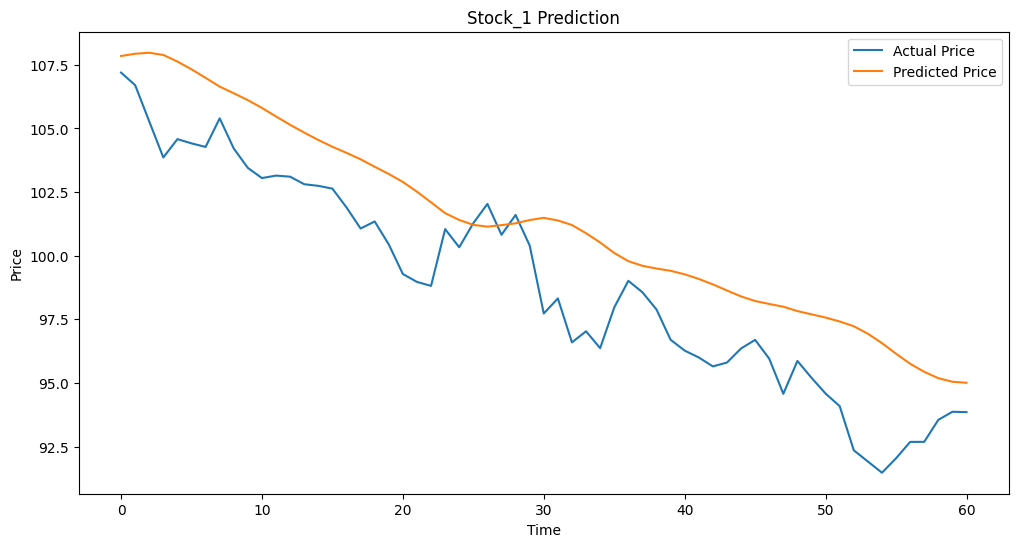

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.title('Stock_1 Prediction')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()

plt.show()

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.723637218152869
MAE: 2.4459919471571325


In [23]:
def prepare_data(stock_column):

    stock = scaled_data[:, stock_column]

    X = []
    y = []

    for i in range(60, len(stock)):
        X.append(stock[i-60:i])
        y.append(stock[i])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    split = int(len(X)*0.8)

    return (
        X[:split],
        X[split:],
        y[:split],
        y[split:]
    )

In [24]:
X_train, X_test, y_train, y_test = prepare_data(0)

In [25]:
stock_names = [
    "Stock_1",
    "Stock_2",
    "Stock_3",
    "Stock_4",
    "Stock_5"
]

In [26]:
for i in range(5):

    X_train, X_test, y_train, y_test = prepare_data(i)

    # train model

    # predict

    # save results

In [27]:
results = {}

In [29]:
results["Stock_1"] = {
    "rmse": rmse,
    "mae": mae,
    "latest_actual": actual_prices[-1],
    "latest_prediction": predicted_prices[-1]
}

In [30]:
print(results["Stock_1"])


{'rmse': np.float64(2.723637218152869), 'mae': 2.4459919471571325, 'latest_actual': np.float64(93.85531666017228), 'latest_prediction': np.float64(95.00802250689448)}


In [33]:
def train_stock(stock_index):
    print(stock_index)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

def train_stock(stock_index):

    stock = scaled_data[:, stock_index]

    X = []
    y = []

    for i in range(60, len(stock)):
        X.append(stock[i-60:i])
        y.append(stock[i])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    split = int(len(X) * 0.8)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    model = Sequential()

    model.add(LSTM(50, return_sequences=True,
                   input_shape=(60,1)))

    model.add(Dropout(0.2))

    model.add(LSTM(50))

    model.add(Dropout(0.2))

    model.add(Dense(25))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    predictions = model.predict(X_test, verbose=0)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    return {
        "rmse": rmse,
        "mae": mae
    }

In [35]:
results = {}

for i in range(5):
    results[f"Stock_{i+1}"] = train_stock(i)

print(results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

{'Stock_1': {'rmse': np.float64(0.07520006925986875), 'mae': 0.06521670978394947}, 'Stock_2': {'rmse': np.float64(0.03716572140975077), 'mae': 0.030106545594532252}, 'Stock_3': {'rmse': np.float64(0.13422135328280538), 'mae': 0.1197462468954469}, 'Stock_4': {'rmse': np.float64(0.10249986586442345), 'mae': 0.07999337809546637}, 'Stock_5': {'rmse': np.float64(0.11342462496146032), 'mae': 0.0992944425229173}}


In [36]:
import pandas as pd

results_df = pd.DataFrame(results).T

print(results_df)

             rmse       mae
Stock_1  0.075200  0.065217
Stock_2  0.037166  0.030107
Stock_3  0.134221  0.119746
Stock_4  0.102500  0.079993
Stock_5  0.113425  0.099294


In [37]:
df["Market_Index"] = df.mean(axis=1)

In [38]:
print(df[["Market_Index"]].head())

            Market_Index
Date                    
2020-01-01    100.618129
2020-01-02    100.798721
2020-01-03    100.678258
2020-01-04    100.871261
2020-01-05    101.683139


In [39]:
from sklearn.preprocessing import MinMaxScaler

market_scaler = MinMaxScaler()

market_data = market_scaler.fit_transform(
    df[["Market_Index"]]
)

In [40]:
X = []
y = []

for i in range(60, len(market_data)):
    X.append(market_data[i-60:i])
    y.append(market_data[i])

X = np.array(X)
y = np.array(y)

In [41]:
current_value = actual_prices[-1]
predicted_value = predicted_prices[-1]

if predicted_value > current_value:
    trend = "Bullish 📈"
else:
    trend = "Bearish 📉"

print(trend)

Bullish 📈


In [42]:
results_df["Rank"] = results_df["rmse"].rank()

In [43]:
best_stock = results_df["rmse"].idxmin()

print("Recommended:", best_stock)

Recommended: Stock_2
